In [ ]:
# Фрактал 1
import matplotlib.pyplot as plt
import math


# Клас для двовимірної L-системи
class LSystem2D:
    def __init__(self, axiom, width, length, angle):
        self.axiom = axiom           # Початковий рядок
        self.state = axiom           # Поточний стан
        self.width = width           # Товщина лінії
        self.length = length         # Довжина одного сегмента
        self.angle = angle           # Кут повороту
        self.rules = {}              # Правила переписування

    # Додаємо правила переписування
    def add_rules(self, *rules):
        for key, value in rules:
            self.rules[key] = value

    # Генерація нового шляху на основі ітерацій
    def generate_path(self, n_iter):
        for _ in range(n_iter):
            new_state = ""
            for char in self.state:
                if char in self.rules:
                    new_state += self.rules[char].lower()  # щоб уникнути повторної заміни
                else:
                    new_state += char
            self.state = new_state.upper()  # Повертаємо до верхнього регістру

    # Малювання через matplotlib
    def draw_turtle(self, start_pos, start_angle):
        x, y = start_pos
        current_angle = start_angle

        lines_x = []
        lines_y = []

        for move in self.state:
            if move == 'F':  # Малюємо лінію вперед
                new_x = x + self.length * math.cos(math.radians(current_angle))
                new_y = y + self.length * math.sin(math.radians(current_angle))

                lines_x.extend([x, new_x, None])
                lines_y.extend([y, new_y, None])

                x, y = new_x, new_y

            elif move == 'S':  # Переміщення без сліду
                x = x + self.length * math.cos(math.radians(current_angle))
                y = y + self.length * math.sin(math.radians(current_angle))

            elif move == '+':  # Поворот вліво
                current_angle += self.angle

            elif move == '-':  # Поворот вправо
                current_angle -= self.angle

        plt.figure(figsize=(14, 7))
        plt.plot(lines_x, lines_y, linewidth=self.width)
        plt.axis("equal")
        plt.axis("off")
        plt.show()

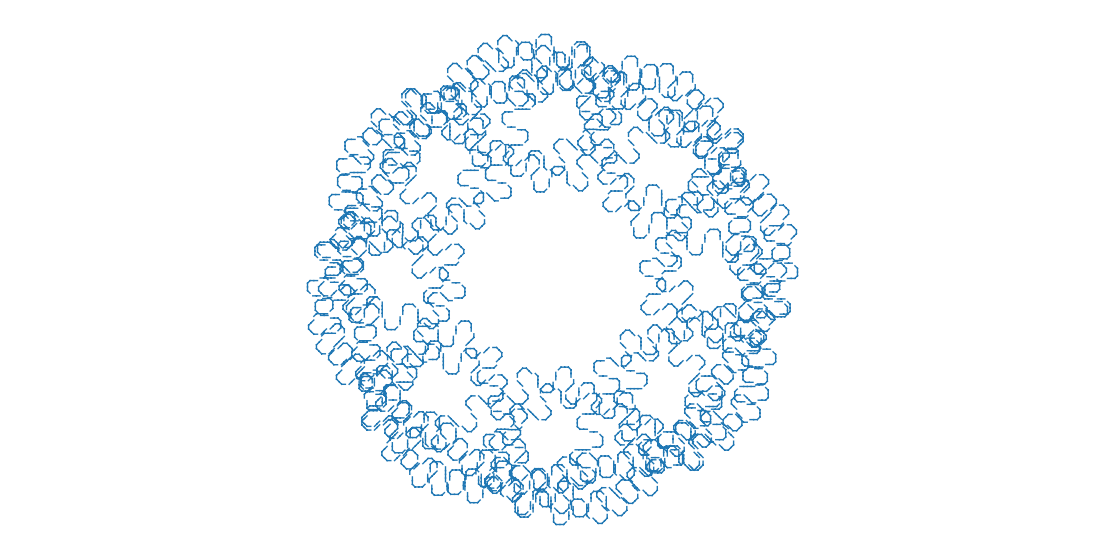

In [ ]:

width = 1200
height = 600

pen_width = 1
f_len = 5
angle = 45
axiom = "F+F+F+F"

l_sys = LSystem2D(axiom, pen_width, f_len, angle)
l_sys.add_rules(
    ("F", "F+S-FF+F+FF+FS+FF-S+FF-F-FF-FS-FFF+F+S-FF+F+FF+FS+FF-S+FF-F-FF-FS-FFF"),
    ("S", "S")
)
l_sys.generate_path(2)
l_sys.draw_turtle((0, 0), 0)

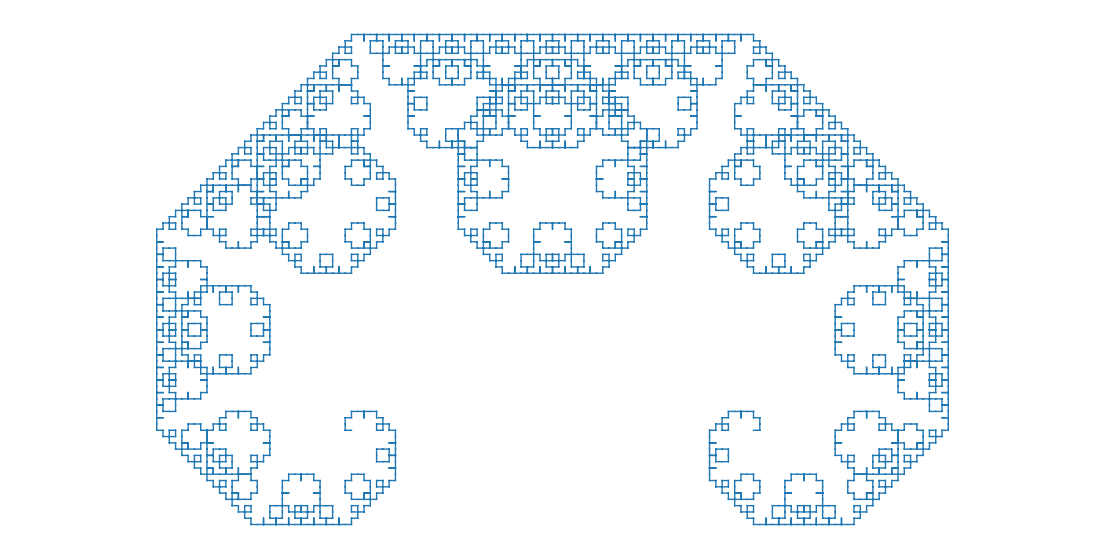

In [ ]:
f_len = 2
angle = 45
axiom = "F"

l_sys = LSystem2D(axiom, width=1, length=f_len, angle=angle)
l_sys.add_rules(("F", "+F--F+"))

l_sys.generate_path(12)
l_sys.draw_turtle((0, 0), 0)

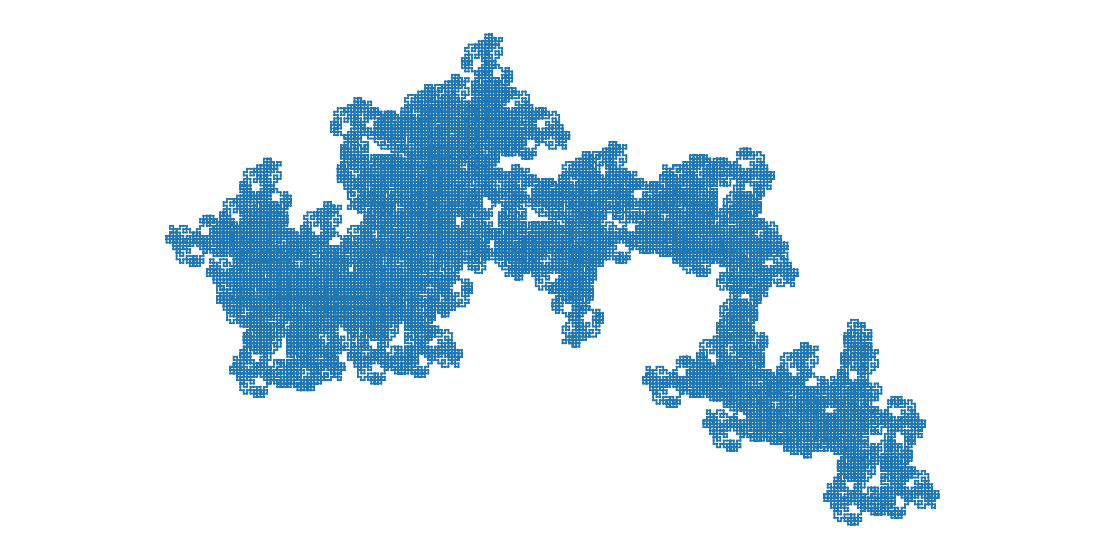

In [ ]:
f_len = 4
angle = 90
axiom = "FX"

l_sys = LSystem2D(axiom, width=1.2, length=f_len, angle=angle)

l_sys.add_rules(
    ("X", "X+YF+N--F+F+F+Y"),
    ("Y", "-FX-Y")
)

l_sys.generate_path(12)

l_sys.draw_turtle((0, 0), 0)